### Imports

In [ ]:
#imports 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# pour avoir des resultats reproductibles
SEED = 42
np.random.seed(SEED)         # Celui de  NumPy 
torch.manual_seed(SEED)      # Celui de Pytorch

### 1. Chargement et préparation des données
- Nous commençons par charger les trajectoires
- On construit les labels
- 

In [2]:
# --- 1. Chargement et préparation des données ---
# Charger les trajectoires des 2 classes
data_class1 = np.load("class1_trajectories.npy")  
data_class2 = np.load("class2_trajectories.npy")  
# On ajoute la 3eme classe manquante
data_class3 = np.load("class3_trajectories.npy")
data = np.concatenate((data_class1, data_class2, data_class3))    
    
# Construction des labels ---
labels = np.concatenate((np.zeros(data_class1.shape[0]), np.ones(data_class2.shape[0]), 2*np.ones(data_class3.shape[0])))

### 2. Split train/val/test set

In [3]:
# --- 2. Split train/val/test ---
n_samples = data.shape[0]
indices = np.arange(n_samples)
np.random.seed(30)

# est ce la bonne façon de faire? et si les class split ne sont pas équilibrées?
np.random.shuffle(indices) 

train_size = int(0.8 * n_samples)
val_size = int(0.1 * n_samples)
test_size = n_samples - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

train_data = data[train_indices]
train_labels = labels[train_indices]
val_data = data[val_indices]
val_labels = labels[val_indices]
test_data = data[test_indices]
test_labels = labels[test_indices]

#### 3. Normalisation eventuelle
- nous devons normalizer les données pour que les trajectoires soient comparables et bien sur stabiliser et eviter unstable training 
- pour cela nous utilisons z score normalization : https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-and-examples/ cette normalization centre les données et les reduit a une variance de 1
- Pour chaque trajectoire, nous calculons la moyenne et l'ecart type
- On normalise les données en subtractant la moyenne et en divisant par l'écart type
- On peut aussi essayer min-max normalization : https://medium.com/@abhi1achiever/min-max-normalization-db1f515b08b4


In [ ]:
#on reshape les données pour que chaque trajectoire soit une seule ligne
train_flat = train_data.reshape(-1, train_data.shape[-1])
#on calcule la moyenne et l'écart type de chaque trajectoire
mean = train_flat.mean(axis=0)
std = train_flat.std(axis=0)
std = np.where(std == 0, 1e-6, std) #pour eviter la division par 0 (RuntimeWarning: invalid value encountered in divide)

#on essaie d'abord de normaliser les données
train_normalized = (train_data - mean)/std
val_normalized = (val_data - mean)/std
test_normalized = (test_data - mean)/std




#### 4. Data augmentation 
- Comment augmenter sans fausser les données? 

In [5]:
#TODO data augmentation 

#### 4.  data pytorch pour la classification

In [6]:

# --- 3. Dataset PyTorch pour la classification ---
class TrajectoryClassificationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):# pour récupérer un échantillon (x, y) dans le dataset
        x = self.data[idx]
        y = self.labels[idx] #on prend le label de l'echantillon
        return torch.FloatTensor(x), torch.LongTensor([y])

#### Création des datasets et dataloaders

In [7]:
# On crée les datasets
train_dataset = TrajectoryClassificationDataset(train_normalized, train_labels)
val_dataset = TrajectoryClassificationDataset(val_normalized, val_labels)
test_dataset = TrajectoryClassificationDataset(test_normalized, test_labels)

# On créé les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### 4. Modèle pour la classification

In [ ]:
class MonModele(nn.Module):
    def __init__(self, input_size=20, hidden_size = 64, num_layers=2, output_size=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2) # pour eviter le surapprentissage
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.lstm(x) #nous donne la sortie de la derniere couche LSTM
        x = self.dropout(x) #applique dropout
        x = self.fc(x[:, -1, :]) #nous donne la sortie de la derniere couche FC
        return x

#### fonctions helpers

In [9]:
#fonction pour calculer la norme du gradient
#on calcule la norme du gradient pour visualiser l'exploding gradient

def grad_norm_cal(model):
    total_norm = 0.0
    for i in model.parameters():
        if i.grad is None:
            continue
        param_norm = i.grad.data.norm(2).item()
        total_norm += param_norm ** 2
    total_norm = total_norm ** 0.5
    return total_norm

#### 5.Instanciation

In [10]:
model = MonModele(input_size=20, hidden_size = 64, num_layers=2, output_size=3, dropout=0.2)
criterion = nn.CrossEntropyLoss() #nous utilisons la fonction de perte CrossEntropyLoss
optimizer = optim.Adam(model.parameters(), lr=0.001) #nous utilisons l'optimiseur Adam

n_epochs = 40 #nous utilisons 10 epochs pour l'entrainement
train_losses, val_losses = [], []
train_accs, val_accs = [], []

#### Entrainement


In [ ]:
#grad_norms = []
for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    correct = 0
    total = 0
    for x_batch, y_batch in train_loader:
        y_batch = y_batch.squeeze()  #nous transformons les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
        optimizer.zero_grad()
        #on calcule la prediction
        y_pred = model(x_batch) 
        #nous calculons la fonction de perte
        loss = criterion(y_pred, y_batch) 
        #on calcule le gradient de la fonction de perte
        loss.backward() 
        # on applique la technique de gradient clipping pour eviter l'exploding gradient 
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 
        
        #on calcule la norme du gradient pour visualiser l'exploding gradient
        grad_norms.append(grad_norm_cal(model))

        #on met a jour les parametres du modele
        optimizer.step() 
        #nous sommons les pertes moyennes pour chaque batch
        epoch_train_loss += loss.item() * x_batch.size(0) #on multiplie par le nombre d'echantillons pour avoir la moyenne par rapport au nombre d'echantillons
        #on donne la prediction du modele
        _, predicted = torch.max(y_pred.data, 1) 
        #on ajoute le nombre d'echantillons a la liste des total
        total += y_batch.size(0) 
        #on compte le nombre de prédictions correctes et les additionnons dans le compteur "correct"
        correct += (predicted == y_batch.squeeze()).sum().item() 
    train_losses.append(epoch_train_loss / total) #nous calculons la moyenne des loss par époque d'entrainement et l'ajoutons à la liste des train_losses
    train_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante
    # Validation
    model.eval()
    epoch_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            #on transforme les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
            y_batch = y_batch.squeeze() 
            #on calcule la prediction
            y_pred = model(x_batch) 
            #on calcule la fonction de perte
            loss = criterion(y_pred, y_batch) 
            epoch_val_loss += loss.item() #nous sommons les pertes moyennes pour chaque batch
            _, predicted = torch.max(y_pred.data, 1) #nous donne la prediction du modele
            total += y_batch.size(0) #nous ajoutons le nombre d'echantillons a la liste des total
            correct += (predicted == y_batch.squeeze()).sum().item() #nous comptons le nombre de prédictions correctes et les additionnons dans le compteur "correct"
    val_losses.append(epoch_val_loss / len(val_loader)) #nous calculons la moyenne des loss par époque de validation et l'ajoutons à la liste des train_losses
    val_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante

    print(f"Epoch {epoch+1}/{n_epochs}, Train loss: {train_losses[-1]:.4f}, Val loss: {val_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}%, Val Acc: {val_accs[-1]:.2f}%")

Epoch 1/40, Train loss: 1.1003, Val loss: 1.1021, Train Acc: 34.36%, Val Acc: 25.00%
Epoch 2/40, Train loss: 1.0991, Val loss: 1.1048, Train Acc: 34.53%, Val Acc: 25.00%
Epoch 3/40, Train loss: 1.0966, Val loss: 1.0951, Train Acc: 40.23%, Val Acc: 36.84%
Epoch 4/40, Train loss: 1.0734, Val loss: 0.9669, Train Acc: 39.58%, Val Acc: 36.84%
Epoch 5/40, Train loss: 0.8334, Val loss: 0.7217, Train Acc: 59.93%, Val Acc: 71.05%
Epoch 6/40, Train loss: 0.9170, Val loss: 0.6205, Train Acc: 61.56%, Val Acc: 73.68%
Epoch 7/40, Train loss: 0.9033, Val loss: 0.7124, Train Acc: 52.61%, Val Acc: 72.37%
Epoch 8/40, Train loss: 0.8554, Val loss: 0.7208, Train Acc: 57.00%, Val Acc: 71.05%
Epoch 9/40, Train loss: 0.8563, Val loss: 0.7195, Train Acc: 57.00%, Val Acc: 72.37%
Epoch 10/40, Train loss: 0.8537, Val loss: 0.7245, Train Acc: 57.17%, Val Acc: 72.37%
Epoch 11/40, Train loss: 0.8555, Val loss: 0.7087, Train Acc: 57.17%, Val Acc: 72.37%
Epoch 12/40, Train loss: 0.8498, Val loss: 0.7276, Train Acc: 5

#### Visualisation

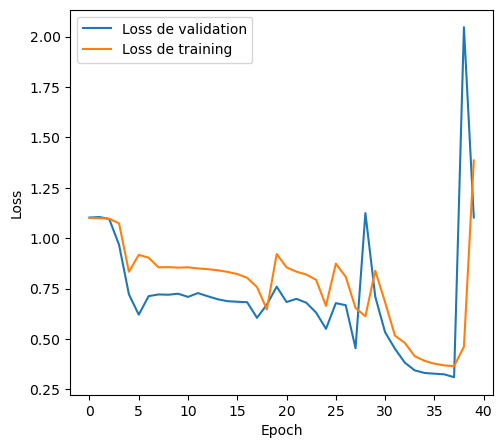

In [15]:
def visualize_validation(val_losses, train_losses):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(val_losses, label='Loss de validation')
    plt.plot(train_losses, label='Loss de training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
visualize_validation(val_losses, train_losses)

#### 7. Evaluation sur le test set

In [16]:
def evaluate_on_test(model, test_loader, criterion):
    model.eval()
    epoch_test_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    test_losses, test_accs = [], []

    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            y_batch = y_batch.squeeze()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            epoch_test_loss += loss.item()
            
            
            _, predicted = torch.max(y_pred.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            
            all_predictions.extend(predicted.numpy())
            all_labels.extend(y_batch.numpy())
    
    accuracy = 100 * correct / total
    avg_loss = epoch_test_loss / len(test_loader)
    
    print(f"results sur le test set ")
    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accu: {accuracy:.2f}%")
    print(f"Correct: {correct}/{total}")    
    return accuracy, avg_loss, all_predictions, all_labels

#### l'evaluation


In [17]:
test_acc, test_loss, predictions, true_labels = evaluate_on_test(model, test_loader, criterion)
"""
plt.plot(grad_norms)
plt.xlabel("step")
plt.ylabel("grad norm")
plt.title("norme du gradient")
plt.show()
"""


results sur le test set 
Test loss: 1.0987
Test accu: 32.05%
Correct: 25/78


'\nplt.plot(grad_norms)\nplt.xlabel("step")\nplt.ylabel("grad norm")\nplt.title("norme du gradient")\nplt.show()\n'